In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

In [3]:
data = {
    'PM2.5': [30,40,60,80,100,120,150,200,50,70],
    'PM10': [50,60,90,120,150,180,200,250,70,110],
    'NO2': [20,25,35,40,50,60,70,90,30,45],
    'CO': [0.5,0.6,0.8,1.2,1.5,2.0,2.5,3.0,0.7,1.0],
    'SO2': [10,12,15,20,25,30,35,40,14,18],
    'AQI': [45,55,85,120,180,220,300,350,70,110]
}

df = pd.DataFrame(data)
df

,PM2.5,PM10,NO2,CO,SO2,AQI
0,30,50,20,0.5,10,45
1,40,60,25,0.6,12,55
2,60,90,35,0.8,15,85
3,80,120,40,1.2,20,120
4,100,150,50,1.5,25,180
5,120,180,60,2.0,30,220
6,150,200,70,2.5,35,300
7,200,250,90,3.0,40,350
8,50,70,30,0.7,14,70
9,70,110,45,1.0,18,110


In [4]:
X = df[['PM2.5','PM10','NO2','CO','SO2']]
y = df['AQI']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [6]:
model = RandomForestRegressor()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [7]:
accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9637950000000001


In [8]:
pm25 = float(input("Enter PM2.5: "))
pm10 = float(input("Enter PM10: "))
no2 = float(input("Enter NO2: "))
co = float(input("Enter CO: "))
so2 = float(input("Enter SO2: "))

prediction = model.predict([[pm25, pm10, no2, co, so2]])
aqi = prediction[0]

print("Predicted AQI:", aqi)

Enter PM2.5:  60
Enter PM10:  90
Enter NO2:  35
Enter CO:  0.8
Enter SO2:  15


Predicted AQI: 80.6


C:\Users\anwes\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [9]:
if aqi <= 50:
    print("Air Quality: Good 😊")
elif aqi <= 100:
    print("Air Quality: Moderate 😐")
elif aqi <= 200:
    print("Air Quality: Poor 😷")
else:
    print("Air Quality: Very Poor 🚨")

Air Quality: Moderate 😐


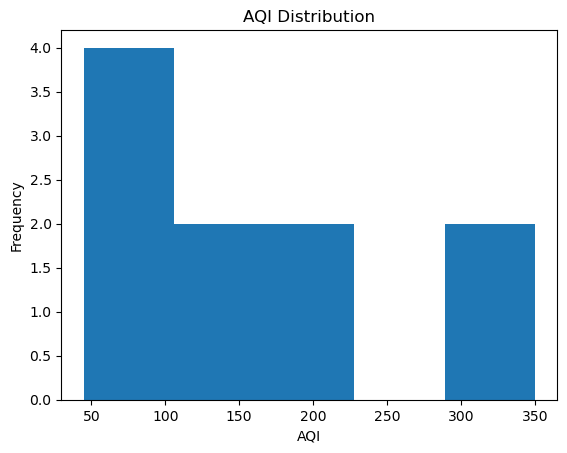

In [10]:
plt.hist(df['AQI'], bins=5)
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.title("AQI Distribution")
plt.show()

In [ ]:
# GUI code
import tkinter as tk
from tkinter import messagebox
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

# ------------------ TRAIN MODEL ------------------
data = {
    'PM2.5': [30,40,60,80,100,120,150,200,50,70],
    'PM10': [50,60,90,120,150,180,200,250,70,110],
    'NO2': [20,25,35,40,50,60,70,90,30,45],
    'CO': [0.5,0.6,0.8,1.2,1.5,2.0,2.5,3.0,0.7,1.0],
    'SO2': [10,12,15,20,25,30,35,40,14,18],
    'AQI': [45,55,85,120,180,220,300,350,70,110]
}

df = pd.DataFrame(data)

X = df[['PM2.5','PM10','NO2','CO','SO2']]
y = df['AQI']

model = RandomForestRegressor()
model.fit(X, y)

# ------------------ FUNCTION ------------------
def predict_aqi():
    try:
        pm25 = float(entry_pm25.get())
        pm10 = float(entry_pm10.get())
        no2 = float(entry_no2.get())
        co = float(entry_co.get())
        so2 = float(entry_so2.get())

        input_data = pd.DataFrame([[pm25, pm10, no2, co, so2]],
                                  columns=['PM2.5','PM10','NO2','CO','SO2'])

        prediction = model.predict(input_data)
        aqi = prediction[0]

        # AQI Category + Color
        if aqi <= 50:
            category = "Good 😊"
            color = "green"
        elif aqi <= 100:
            category = "Moderate 😐"
            color = "orange"
        elif aqi <= 200:
            category = "Poor 😷"
            color = "red"
        else:
            category = "Very Poor 🚨"
            color = "darkred"

        result_label.config(text=f"AQI: {aqi:.2f}\n{category}", fg=color)

    except:
        messagebox.showerror("Invalid Input", "Please enter numeric values only!")

# ------------------ GUI DESIGN ------------------
root = tk.Tk()
root.title("Air Quality Prediction System")
root.geometry("420x500")
root.configure(bg="#f0f4f7")

title = tk.Label(root, text="🌍 Air Quality Prediction", 
                 font=("Arial", 16, "bold"), bg="#f0f4f7")
title.pack(pady=10)

subtitle = tk.Label(root, text="Enter pollution values below:",
                    font=("Arial", 10), bg="#f0f4f7")
subtitle.pack(pady=5)

# Input frame
frame = tk.Frame(root, bg="#f0f4f7")
frame.pack(pady=10)

def create_input(label_text):
    tk.Label(frame, text=label_text, font=("Arial", 11), bg="#f0f4f7").pack()
    entry = tk.Entry(frame, font=("Arial", 11), justify="center")
    entry.pack(pady=5)
    return entry

entry_pm25 = create_input("PM2.5")
entry_pm10 = create_input("PM10")
entry_no2 = create_input("NO2")
entry_co = create_input("CO")
entry_so2 = create_input("SO2")

# Predict button
btn = tk.Button(root, text="Predict AQI", command=predict_aqi,
                font=("Arial", 12, "bold"), bg="#007BFF", fg="white",
                padx=10, pady=5)
btn.pack(pady=15)

# Result label
result_label = tk.Label(root, text="", font=("Arial", 14, "bold"), bg="#f0f4f7")
result_label.pack(pady=10)

# Footer
footer = tk.Label(root, text="AI Project | Air Quality System",
                  font=("Arial", 8), bg="#f0f4f7", fg="gray")
footer.pack(side="bottom", pady=10)

# Run app
root.mainloop()